In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

print("✓ All libraries imported")
print(f"Pandas:  {pd.__version__}")
print(f"NumPy:   {np.__version__}")

✓ All libraries imported
Pandas:  3.0.3
NumPy:   2.4.6


In [13]:
print(os.listdir('data/raw'))

['    d1namo']


In [17]:
df_raw = pd.read_csv('data/raw/d1namo/diabetes_subset_pictures-glucose-food-insulin/001/glucose.csv')

print("Shape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nFirst 10 rows:")
print(df_raw.head(10))
print("\nData types:")
print(df_raw.dtypes)

Shape: (1438, 5)

Column names: ['date', 'time', 'glucose', 'type', 'comments']

First 10 rows:
         date      time  glucose    type  comments
0  2014-10-01  19:14:00     10.3     cgm       NaN
1  2014-10-01  19:19:00      9.9     cgm       NaN
2  2014-10-01  19:23:00      9.4  manual       NaN
3  2014-10-01  19:24:00      9.8     cgm       NaN
4  2014-10-01  19:29:00      9.6     cgm       NaN
5  2014-10-01  19:34:00      9.4     cgm       NaN
6  2014-10-01  19:39:00      9.2     cgm       NaN
7  2014-10-01  19:44:00      8.9     cgm       NaN
8  2014-10-01  19:49:00      8.7     cgm       NaN
9  2014-10-01  19:54:00      8.4     cgm       NaN

Data types:
date            str
time            str
glucose     float64
type            str
comments    float64
dtype: object


In [18]:
def load_patient(patient_folder):
    """
    Load one D1NAMO patient's CGM glucose data.
    Converts mmol/L to mg/dL, filters to CGM only,
    combines date+time into a single timestamp column.
    """
    path = f'data/raw/d1namo/diabetes_subset_pictures-glucose-food-insulin/{patient_folder}/glucose.csv'
    df = pd.read_csv(path)
    
    # keep only CGM readings (filter out manual fingersticks)
    df = df[df['type'] == 'cgm'].copy()
    
    # combine date and time into one timestamp column
    df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['time'])
    
    # convert mmol/L to mg/dL (multiply by 18)
    df['glucose'] = df['glucose'] * 18
    
    # keep only what we need
    df = df[['timestamp', 'glucose']].sort_values('timestamp').reset_index(drop=True)
    
    return df

# test on patient 001
df = load_patient('001')

print("Shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))
print("\nGlucose stats (mg/dL):")
print(df['glucose'].describe())

Shape: (1413, 2)

First 10 rows:
            timestamp  glucose
0 2014-10-01 19:14:00    185.4
1 2014-10-01 19:19:00    178.2
2 2014-10-01 19:24:00    176.4
3 2014-10-01 19:29:00    172.8
4 2014-10-01 19:34:00    169.2
5 2014-10-01 19:39:00    165.6
6 2014-10-01 19:44:00    160.2
7 2014-10-01 19:49:00    156.6
8 2014-10-01 19:54:00    151.2
9 2014-10-01 19:59:00    147.6

Glucose stats (mg/dL):
count    1413.000000
mean      183.650955
std        87.644327
min        39.600000
25%       124.200000
50%       172.800000
75%       232.200000
max       399.600000
Name: glucose, dtype: float64


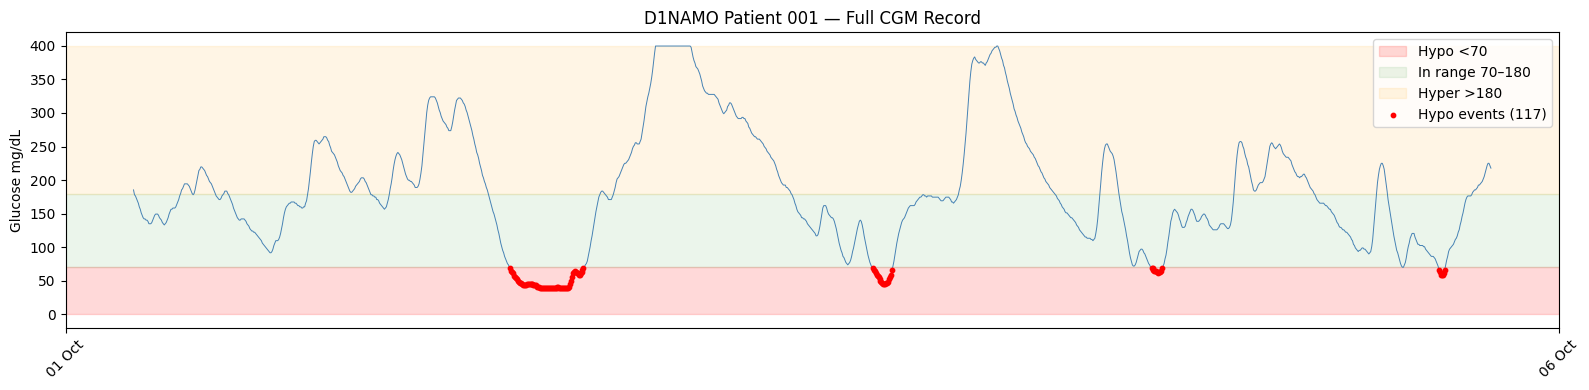

Total readings: 1413
Hypo readings (<70):  117 (8.3%)
In range (70-180):    673 (47.6%)
Hyper readings (>180): 623 (44.1%)


In [19]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df['timestamp'], df['glucose'], linewidth=0.7, color='steelblue')

# danger zones you know personally
ax.axhspan(0,   70,  alpha=0.15, color='red',    label='Hypo <70')
ax.axhspan(70,  180, alpha=0.08, color='green',  label='In range 70–180')
ax.axhspan(180, 400, alpha=0.10, color='orange', label='Hyper >180')

# mark the actual hypo events as red dots
hypos = df[df['glucose'] < 70]
ax.scatter(hypos['timestamp'], hypos['glucose'], 
           color='red', s=10, zorder=5, label=f'Hypo events ({len(hypos)})')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator())
plt.xticks(rotation=45)
ax.set_ylabel('Glucose mg/dL')
ax.set_title('D1NAMO Patient 001 — Full CGM Record')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total readings: {len(df)}")
print(f"Hypo readings (<70):  {(df['glucose'] < 70).sum()} ({(df['glucose'] < 70).mean()*100:.1f}%)")
print(f"In range (70-180):    {df['glucose'].between(70,180).sum()} ({df['glucose'].between(70,180).mean()*100:.1f}%)")
print(f"Hyper readings (>180): {(df['glucose'] > 180).sum()} ({(df['glucose'] > 180).mean()*100:.1f}%)")

In [20]:
# CELL 4 — Feature Engineering
# these are the features your LSTM will use

df['delta_1']  = df['glucose'].diff()        # change in last 5 mins
df['delta_3']  = df['glucose'].diff(3)       # change in last 15 mins  
df['delta_6']  = df['glucose'].diff(6)       # change in last 30 mins
df['rolling_mean_12'] = df['glucose'].rolling(12).mean()  # 1hr average
df['rolling_std_12']  = df['glucose'].rolling(12).std()   # 1hr volatility
df['hour']     = df['timestamp'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['is_hypo']  = df['glucose'] < 70

print(df[['timestamp','glucose','delta_1','delta_3','delta_6']].head(10))

            timestamp  glucose  delta_1  delta_3  delta_6
0 2014-10-01 19:14:00    185.4      NaN      NaN      NaN
1 2014-10-01 19:19:00    178.2     -7.2      NaN      NaN
2 2014-10-01 19:24:00    176.4     -1.8      NaN      NaN
3 2014-10-01 19:29:00    172.8     -3.6    -12.6      NaN
4 2014-10-01 19:34:00    169.2     -3.6     -9.0      NaN
5 2014-10-01 19:39:00    165.6     -3.6    -10.8      NaN
6 2014-10-01 19:44:00    160.2     -5.4    -12.6    -25.2
7 2014-10-01 19:49:00    156.6     -3.6    -12.6    -21.6
8 2014-10-01 19:54:00    151.2     -5.4    -14.4    -25.2
9 2014-10-01 19:59:00    147.6     -3.6    -12.6    -25.2


In [21]:
# CELL 5 — The most important analysis you'll do in Phase 1
# what is the rate of change 30 mins BEFORE a hypo vs normal?

pre_hypo_mask = df['is_hypo'].shift(-6).fillna(False)

print("=== Rate of change (delta_6) 30 mins BEFORE a hypo ===")
print(df[pre_hypo_mask]['delta_6'].describe())

print("\n=== Rate of change (delta_6) during normal readings ===")
print(df[~df['is_hypo']]['delta_6'].describe())

=== Rate of change (delta_6) 30 mins BEFORE a hypo ===
count    117.000000
mean      -8.107692
std       12.676520
min      -45.000000
25%      -14.400000
50%       -7.200000
75%        0.000000
max       23.400000
Name: delta_6, dtype: float64

=== Rate of change (delta_6) during normal readings ===
count    1290.000000
mean        0.560930
std        26.655194
min       -63.000000
25%       -16.200000
50%        -5.400000
75%        12.600000
max       109.800000
Name: delta_6, dtype: float64


Hypo episodes found: 117


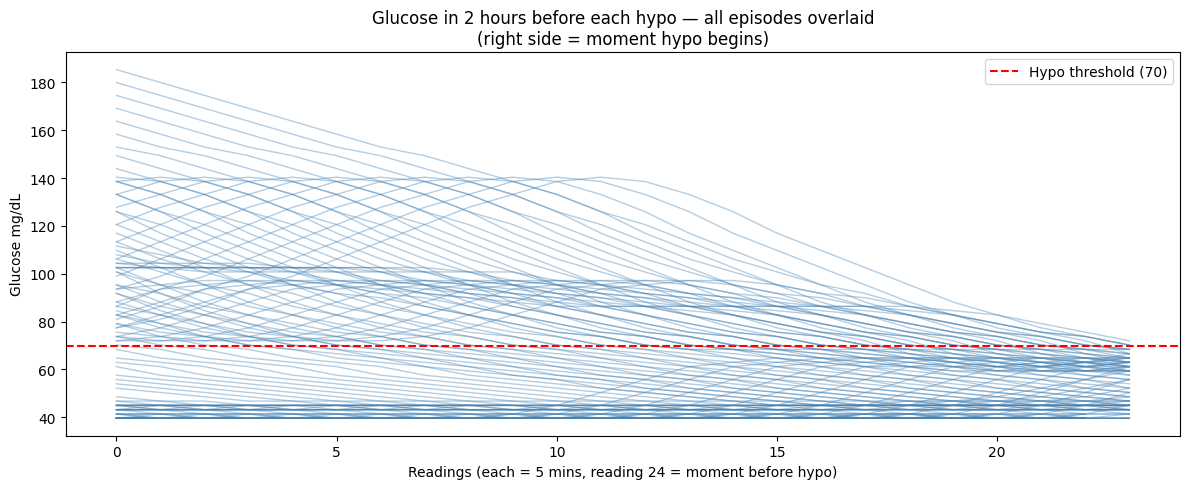

In [22]:
# CELL 6 — Visualise pre-hypo windows
# what does the glucose curve look like in the 2 hours before each hypo?

def get_pre_hypo_windows(df, lookback=24):
    windows = []
    # find where each hypo episode starts
    hypo_starts = df[
        df['is_hypo'] & ~df['is_hypo'].shift(1).fillna(False)
    ]['timestamp']
    
    for start in hypo_starts:
        window = df[
            (df['timestamp'] >= start - pd.Timedelta(hours=2)) &
            (df['timestamp'] < start)
        ]
        if len(window) >= 12:
            windows.append(window['glucose'].values)
    return windows

windows = get_pre_hypo_windows(df)
print(f"Hypo episodes found: {len(windows)}")

fig, ax = plt.subplots(figsize=(12, 5))
for w in windows:
    ax.plot(range(len(w)), w, alpha=0.4, linewidth=1, color='steelblue')
ax.axhline(70, color='red', linestyle='--', linewidth=1.5, label='Hypo threshold (70)')
ax.set_title('Glucose in 2 hours before each hypo — all episodes overlaid\n(right side = moment hypo begins)')
ax.set_xlabel('Readings (each = 5 mins, reading 24 = moment before hypo)')
ax.set_ylabel('Glucose mg/dL')
ax.legend()
plt.tight_layout()
plt.show()

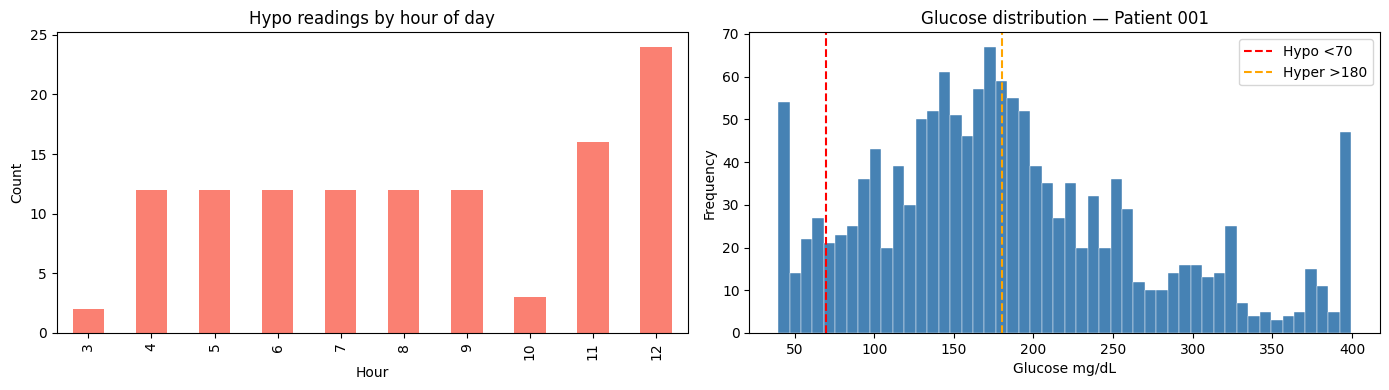

In [23]:
# CELL 7 — When do hypos happen?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# by hour of day
hypo_by_hour = df[df['is_hypo']].groupby('hour').size()
hypo_by_hour.plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Hypo readings by hour of day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

# glucose distribution
axes[1].hist(df['glucose'], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(70,  color='red',   linestyle='--', label='Hypo <70')
axes[1].axvline(180, color='orange',linestyle='--', label='Hyper >180')
axes[1].set_title('Glucose distribution — Patient 001')
axes[1].set_xlabel('Glucose mg/dL')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
# CELL 8 — Load all 9 patients and compare their stats
BASE = 'data/raw/d1namo/diabetes_subset_pictures-glucose-food-insulin'

all_patients = {}
for patient_id in ['001','002','003','004','005','006','007','008','009']:
    try:
        p = load_patient(patient_id)
        # add features
        p['delta_1']  = p['glucose'].diff()
        p['delta_3']  = p['glucose'].diff(3)
        p['delta_6']  = p['glucose'].diff(6)
        p['rolling_mean_12'] = p['glucose'].rolling(12).mean()
        p['rolling_std_12']  = p['glucose'].rolling(12).std()
        p['hour']     = p['timestamp'].dt.hour
        p['hour_sin'] = np.sin(2 * np.pi * p['hour'] / 24)
        p['hour_cos'] = np.cos(2 * np.pi * p['hour'] / 24)
        p['is_hypo']  = p['glucose'] < 70
        p['patient']  = patient_id
        all_patients[patient_id] = p
        
        hypo_pct = (p['glucose'] < 70).mean() * 100
        tir_pct  = p['glucose'].between(70,180).mean() * 100
        print(f"Patient {patient_id}: {len(p):4d} readings | "
              f"Hypo: {hypo_pct:4.1f}% | "
              f"TIR: {tir_pct:4.1f}% | "
              f"Mean: {p['glucose'].mean():.0f} mg/dL")
    except Exception as e:
        print(f"Patient {patient_id}: error — {e}")

print(f"\nTotal patients loaded: {len(all_patients)}")

Patient 001: 1413 readings | Hypo:  8.3% | TIR: 47.6% | Mean: 184 mg/dL
Patient 002: 1056 readings | Hypo: 14.8% | TIR: 36.3% | Mean: 183 mg/dL
Patient 003:  183 readings | Hypo:  0.0% | TIR: 91.8% | Mean: 128 mg/dL
Patient 004:  969 readings | Hypo:  6.4% | TIR: 35.9% | Mean: 202 mg/dL
Patient 005:  909 readings | Hypo:  0.3% | TIR: 68.5% | Mean: 154 mg/dL
Patient 006: 1280 readings | Hypo:  0.8% | TIR: 61.2% | Mean: 170 mg/dL
Patient 007:  988 readings | Hypo:  0.1% | TIR: 83.9% | Mean: 150 mg/dL
Patient 008: 1140 readings | Hypo: 16.1% | TIR: 62.6% | Mean: 130 mg/dL
Patient 009:  117 readings | Hypo: 52.1% | TIR: 47.9% | Mean: 72 mg/dL

Total patients loaded: 9


In [25]:
# CELL 9 — Test the dataset pipeline
import sys
sys.path.append('.')   # so Python can find src/

from src.dataset import GlucoseDataset

# load training and validation sets
train_ds = GlucoseDataset(split='train')
val_ds   = GlucoseDataset(split='val')

# inspect one sample
X_sample, y_sample = train_ds[0]
print(f"\nOne training sample:")
print(f"X shape: {X_sample.shape}  ← (24 timesteps, 8 features)")
print(f"y value: {y_sample.item():.4f}  ← normalised glucose 30 mins ahead")
print(f"\nX first timestep (8 features): {X_sample[0]}")

[train] X shape: torch.Size([6145, 24, 8]) | y shape: torch.Size([6145])
[val] X shape: torch.Size([1541, 24, 8]) | y shape: torch.Size([1541])

One training sample:
X shape: torch.Size([24, 8])  ← (24 timesteps, 8 features)
y value: 0.3289  ← normalised glucose 30 mins ahead

X first timestep (8 features): tensor([ 0.2839, -0.3943, -0.6726, -0.9214, -0.2434,  0.2855, -0.8660,  0.5000])


In [26]:
# CELL 10 — Test the model
from src.model import GlucoseLSTM

model = GlucoseLSTM()
print(model)

# count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal learnable parameters: {total_params:,}")

# test forward pass with one batch
X_batch, y_batch = train_ds[:32]   # grab 32 samples
predictions = model(X_batch)

print(f"\nInput shape:      {X_batch.shape}")
print(f"Predictions shape: {predictions.shape}")
print(f"Target shape:      {y_batch.shape}")
print(f"\nSample predictions: {predictions[:5].detach()}")
print(f"Sample targets:     {y_batch[:5]}")

GlucoseLSTM(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total learnable parameters: 54,337

Input shape:      torch.Size([32, 24, 8])
Predictions shape: torch.Size([32])
Target shape:      torch.Size([32])

Sample predictions: tensor([0.1444, 0.1505, 0.1227, 0.1342, 0.1599])
Sample targets:     tensor([0.3289, 0.3289, 0.3289, 0.3339, 0.3439])


In [28]:
# CELL 11 — Train the model
import sys
sys.path.append('.')

from src.train import train

train_losses, val_losses = train()

Loading data...
[train] X shape: torch.Size([6145, 24, 8]) | y shape: torch.Size([6145])
[val] X shape: torch.Size([1541, 24, 8]) | y shape: torch.Size([1541])


TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

In [29]:
import importlib
import src.train
importlib.reload(src.train)

<module 'src.train' from '/Users/tavle/Desktop/diabloom/src/train.py'>

In [30]:
from src.train import train
train_losses, val_losses = train()

Loading data...
[train] X shape: torch.Size([6145, 24, 8]) | y shape: torch.Size([6145])
[val] X shape: torch.Size([1541, 24, 8]) | y shape: torch.Size([1541])

Model parameters: 54,337
Training samples: 6145
Validation samples: 1541

Starting training for 50 epochs...

 Epoch | Train Loss |   Val Loss | Val MAE (mg/dL)
--------------------------------------------------
     1 |     0.0212 |     0.0122 |         28.9 mg/dL  ✓ saved
     2 |     0.0078 |     0.0084 |         23.1 mg/dL  ✓ saved
     3 |     0.0066 |     0.0071 |         22.0 mg/dL  ✓ saved
     4 |     0.0057 |     0.0069 |         21.1 mg/dL  ✓ saved
     5 |     0.0053 |     0.0072 |         21.7 mg/dL  
     6 |     0.0050 |     0.0072 |         20.6 mg/dL  
     7 |     0.0047 |     0.0066 |         20.1 mg/dL  ✓ saved
     8 |     0.0046 |     0.0073 |         20.8 mg/dL  
     9 |     0.0047 |     0.0062 |         20.3 mg/dL  ✓ saved
    10 |     0.0044 |     0.0059 |         19.2 mg/dL  ✓ saved
    11 |     0.004

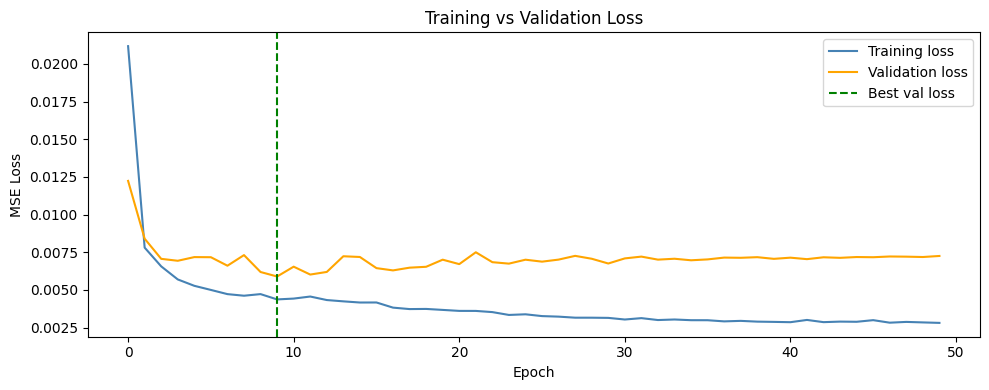

Best val loss at epoch: 10
Best val loss value:    0.0059


In [31]:
# CELL 12 — Loss curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Training loss',   color='steelblue')
ax.plot(val_losses,   label='Validation loss', color='orange')
ax.axvline(x=val_losses.index(min(val_losses)), 
           color='green', linestyle='--', label='Best val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training vs Validation Loss')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best val loss at epoch: {val_losses.index(min(val_losses)) + 1}")
print(f"Best val loss value:    {min(val_losses):.4f}")

[val] X shape: torch.Size([1541, 24, 8]) | y shape: torch.Size([1541])


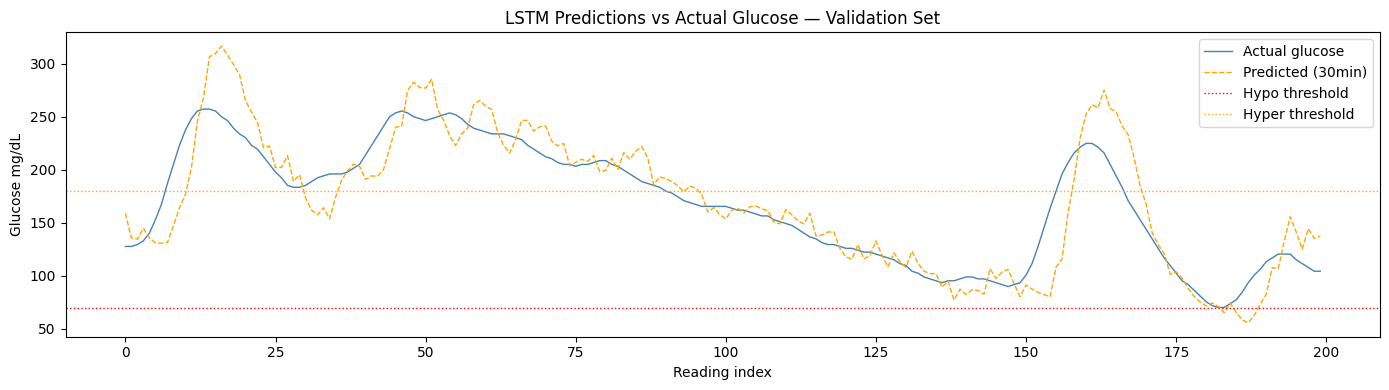

MAE:  18.5 mg/dL
RMSE: 26.7 mg/dL
Hypo direction accuracy: 94.4%


In [32]:
# CELL 13 — Visualise predictions vs actual
import torch
from src.model import GlucoseLSTM
from src.dataset import GlucoseDataset

# load best saved model
model = GlucoseLSTM()
model.load_state_dict(torch.load('models/glucose_lstm.pt'))
model.eval()

# get validation data
val_ds = GlucoseDataset(split='val')
X_val, y_val = val_ds.X, val_ds.y

# run predictions
with torch.no_grad():
    predictions = model(X_val)

# denormalise back to mg/dL
G_MIN, G_MAX = 40, 400
pred_mgdl   = predictions.numpy() * (G_MAX - G_MIN) + G_MIN
actual_mgdl = y_val.numpy()       * (G_MAX - G_MIN) + G_MIN

# plot first 200 readings
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(actual_mgdl[:200], label='Actual glucose',    color='steelblue', linewidth=1)
ax.plot(pred_mgdl[:200],   label='Predicted (30min)', color='orange',    
        linewidth=1, linestyle='--')
ax.axhline(70,  color='red',   linestyle=':', linewidth=1, label='Hypo threshold')
ax.axhline(180, color='orange',linestyle=':', linewidth=1, label='Hyper threshold')
ax.set_title('LSTM Predictions vs Actual Glucose — Validation Set')
ax.set_xlabel('Reading index')
ax.set_ylabel('Glucose mg/dL')
ax.legend()
plt.tight_layout()
plt.show()

# summary stats
mae = np.mean(np.abs(pred_mgdl - actual_mgdl))
rmse = np.sqrt(np.mean((pred_mgdl - actual_mgdl)**2))
print(f"MAE:  {mae:.1f} mg/dL")
print(f"RMSE: {rmse:.1f} mg/dL")

# how often did model correctly identify hypo direction?
actual_hypo = actual_mgdl < 70
pred_hypo   = pred_mgdl   < 70
correct = np.sum(actual_hypo == pred_hypo)
print(f"Hypo direction accuracy: {correct/len(actual_hypo)*100:.1f}%")

In [35]:
# CELL 14 — Test SHAP explanations
import torch
import numpy as np
import sys
sys.path.append('.')

from src.model import GlucoseLSTM
from src.dataset import GlucoseDataset
from src.explain import predict_glucose, get_feature_importance, generate_alert

# load model
model = GlucoseLSTM()
model.load_state_dict(torch.load('models/glucose_lstm.pt'))
model.eval()

# get data
val_ds = GlucoseDataset(split='val')
X_val  = val_ds.X.numpy()   # (1541, 24, 8)
y_val  = val_ds.y.numpy()

# find a window where actual glucose goes low — most interesting to explain
G_MIN, G_MAX = 40, 400
actual_mgdl  = y_val * (G_MAX - G_MIN) + G_MIN
low_indices  = np.where(actual_mgdl < 90)[0]
print(f"Found {len(low_indices)} windows where glucose goes below 90 mg/dL")

# pick the first low glucose window
idx    = low_indices[0]
window = X_val[idx]          # (24, 8)
actual = actual_mgdl[idx]

# predict
predicted = predict_glucose(model, window)
print(f"\nActual glucose:    {actual:.1f} mg/dL")
print(f"Predicted glucose: {predicted:.1f} mg/dL")
print(f"Error:             {abs(predicted - actual):.1f} mg/dL")

# get SHAP explanation (takes ~30 seconds)
print("\nComputing SHAP values (this takes ~30 seconds)...")
importance = get_feature_importance(model, window, X_val)
print("\nFeature importance:")
for feat, val in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(val * 500)
    print(f"  {feat:15s}: {val:.4f}  {bar}")

# generate alert
alert = generate_alert(predicted, importance)
print(f"\n{'='*50}")
print(f"ALERT LEVEL:  {alert['level']}")
print(f"MESSAGE:      {alert['message']}")
print(f"EXPLANATION:  {alert['explanation']}")
print(f"{'='*50}")

[val] X shape: torch.Size([1541, 24, 8]) | y shape: torch.Size([1541])
Found 290 windows where glucose goes below 90 mg/dL

Actual glucose:    86.4 mg/dL
Predicted glucose: 80.6 mg/dL
Error:             5.8 mg/dL

Computing SHAP values (this takes ~30 seconds)...


  0%|          | 0/1 [00:00<?, ?it/s]


Feature importance:
  delta_1        : 0.0091  ████
  glucose        : 0.0015  
  hour_sin       : 0.0013  
  rolling_mean   : 0.0010  
  delta_6        : 0.0009  
  delta_3        : 0.0007  
  hour_cos       : 0.0003  
  rolling_std    : 0.0000  

ALERT LEVEL:  OK
MESSAGE:      Glucose looks stable
EXPLANATION:  None


In [34]:
import importlib
import src.explain
importlib.reload(src.explain)

from src.explain import predict_glucose, get_feature_importance, generate_alert